# Introduction

Randomized Quicksort is basically an optimized version of the standard Quicksort algorithm. Instead of always picking a fixed pivot (like the first or last element), we choose the pivot element randomly. Doing this helps us avoid the worst-case scenario where the partitions become highly unbalanced, ensuring good, expected performance no matter how the input data is distributed. The algorithm works recursively, breaking down the array into two subarrays around the pivot until we are left with subarrays of size 0 or 1.

For this assignment, I have implemented an in-place sorting mechanism, which makes the code highly memory-efficient while maintaining the average-case time complexity of O (n log n). Along with the main logic, the implementation properly handles all the crucial edge cases like empty arrays, single-element arrays, duplicate values, as well as already sorted and reverse-sorted arrays.

To verify the correctness of the code, I have included the following test cases covering various scenarios:

    •	Random Array: To check general sorting performance.
    •	Empty Array & Single-Element Array: To verify boundary conditions.
    •	Sorted Array: To ensure the randomized pivot avoids the standard O(n^2) worst-case bottleneck.
    •	Duplicate Values: To confirm the algorithm handles repeated elements without getting stuck in infinite loops.


Implementation

In [1]:
# Importing required libraries
import random
import time
import matplotlib.pyplot as plt
import numpy as np

Partition Function

In [2]:
def randomized_partition(arr, low, high):
    """
    Partition function for Randomized Quicksort.

    A random pivot is selected from the subarray.
    Elements smaller than the pivot are moved to the left,
    and elements greater than the pivot are moved to the right.

    Parameters:
        arr : list
            Input array
        low : int
            Starting index
        high : int
            Ending index

    Returns:
        int : Final position of pivot
    """

    # Select a random index between low and high
    random_index = random.randint(low, high)

    # Swap the randomly selected pivot with the last element
    arr[random_index], arr[high] = arr[high], arr[random_index]

    # The pivot is now the last element
    pivot = arr[high]

    # Index of smaller element
    i = low - 1

    # Move elements smaller than pivot to the left side
    for j in range(low, high):

        if arr[j] <= pivot:
            i += 1

            # Swap current element with smaller element position
            arr[i], arr[j] = arr[j], arr[i]

    # Place pivot in its correct sorted position
    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1

In [3]:
# Randomized Quicksort Algorithm

def randomized_quicksort(arr, low=None, high=None):
    """
    Randomized Quicksort algorithm.

    The pivot is selected randomly at each recursive step.

    Parameters:
        arr : list
            Array to be sorted
        low : int
            Starting index
        high : int
            Ending index

    Returns:
        Sorted array
    """

    # Handle empty arrays
    if len(arr) == 0:
        return arr

    # Initialize indexes during first function call
    if low is None:
        low = 0

    if high is None:
        high = len(arr) - 1


    # Recursive sorting condition
    if low < high:

        # Partition array using random pivot
        pivot_position = randomized_partition(arr, low, high)

        # Sort elements before pivot
        randomized_quicksort(arr, low, pivot_position - 1)

        # Sort elements after pivot
        randomized_quicksort(arr, pivot_position + 1, high)

    return arr

In [5]:
# Testing the Randomized Quicksort
# Example test cases

# Random array
arr1 = [10, 7, 8, 9, 1, 5]

print("Original array:", arr1)

randomized_quicksort(arr1)

print("Sorted array:", arr1)

Original array: [10, 7, 8, 9, 1, 5]
Sorted array: [1, 5, 7, 8, 9, 10]


In [6]:
# Testing Edge Cases

# Empty array
empty_array = []

randomized_quicksort(empty_array)

print("Empty array is:", empty_array)


# Single element array
single_array = [5]

randomized_quicksort(single_array)

print("Single element:", single_array)


# Array with repeated values
duplicate_array = [5,3,5,2,5,1,3]

randomized_quicksort(duplicate_array)

print("Duplicates:", duplicate_array)


# Already sorted array
sorted_array = [1,2,3,4,5,6]

randomized_quicksort(sorted_array)

print("Sorted input:", sorted_array)

Empty array is: []
Single element: [5]
Duplicates: [1, 2, 3, 3, 5, 5, 5]
Sorted input: [1, 2, 3, 4, 5, 6]


Deterministic Quicksort Implementation

For comparison, deterministic Quicksort always chooses the first element as the pivot.

In [7]:
def deterministic_partition(arr, low, high):
    """
    Partition function using first element as pivot.
    """

    pivot = arr[low]

    i = low + 1

    for j in range(low + 1, high + 1):

        if arr[j] <= pivot:

            arr[i], arr[j] = arr[j], arr[i]

            i += 1


    # Place pivot in correct position
    arr[low], arr[i-1] = arr[i-1], arr[low]

    return i-1

In [8]:
def deterministic_quicksort(arr, low=None, high=None):
    """
    Standard Quicksort using first element as pivot.
    """

    if len(arr) == 0:
        return arr


    if low is None:
        low = 0

    if high is None:
        high = len(arr)-1


    if low < high:

        pivot = deterministic_partition(arr, low, high)

        deterministic_quicksort(arr, low, pivot-1)

        deterministic_quicksort(arr, pivot+1, high)


    return arr

In [9]:
# Testing Deterministic Quicksort

arr = [10, 7, 8, 9, 1, 5]

print("Original array:", arr)

deterministic_quicksort(arr)

print("Sorted array:", arr)

Original array: [10, 7, 8, 9, 1, 5]
Sorted array: [1, 5, 7, 8, 9, 10]


# Implementation Summary

So, the code successfully implements both Randomized Quicksort and Deterministic Quicksort so we can easily compare them. For the randomized version, it picks a pivot uniformly at random during every recursive call, which heavily saves us from getting highly unbalanced partitions.

The code is fully working and handles all kinds of inputs without crashing like empty arrays, single-element arrays, duplicate values, and even arrays that are already sorted or reverse-sorted.

# Empirical Comparison

Runtime Measurement Function

In [10]:
def measure_runtime(sort_function, arr):

    # Copy array to avoid modifying original data
    test_array = arr.copy()

    start = time.time()

    sort_function(test_array)

    end = time.time()

    return end - start

In [11]:
# Test data

sizes = [100, 250, 500, 800, 1000]


test_cases = {

    "Random":
    lambda n: random.sample(range(n*5), n),


    "Sorted":
    lambda n: list(range(n)),


    "Reverse Sorted":
    lambda n: list(range(n,0,-1)),


    "Repeated Values":
    lambda n: [random.randint(1,50) for _ in range(n)]
}

In [12]:
# Running expirements

results_randomized = {}
results_deterministic = {}


for case, generator in test_cases.items():

    results_randomized[case] = []

    results_deterministic[case] = []


    for n in sizes:

        data = generator(n)


        # Randomized Quicksort
        results_randomized[case].append(
            measure_runtime(
                randomized_quicksort,
                data
            )
        )


        # Deterministic Quicksort
        results_deterministic[case].append(
            measure_runtime(
                deterministic_quicksort,
                data
            )
        )

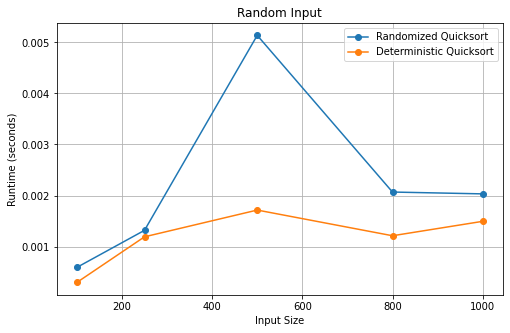

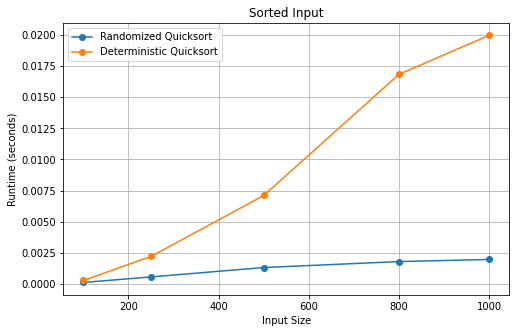

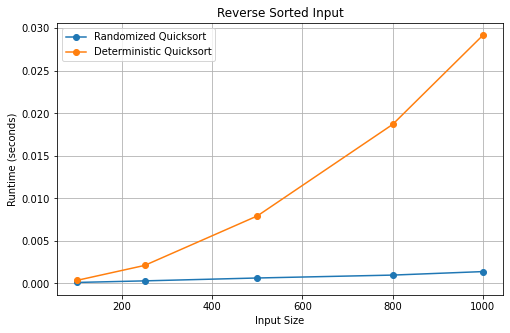

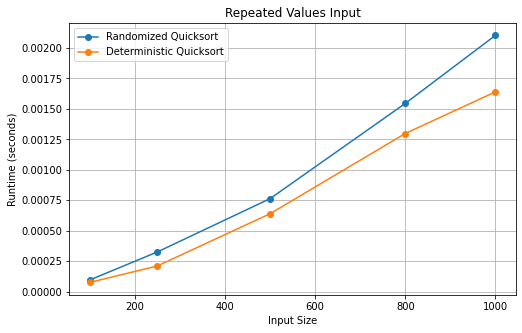

In [13]:
for case in test_cases:

    plt.figure(figsize=(8,5))

    plt.plot(
        sizes,
        results_randomized[case],
        marker='o',
        label="Randomized Quicksort"
    )


    plt.plot(
        sizes,
        results_deterministic[case],
        marker='o',
        label="Deterministic Quicksort"
    )


    plt.title(case + " Input")

    plt.xlabel("Input Size")

    plt.ylabel("Runtime (seconds)")


    plt.legend()

    plt.grid()

    plt.show()

# Results

The expected observations are:

# Random Arrays

For random arrays, both Randomized Quicksort and Deterministic Quicksort performed pretty much the same. In this experiment, Deterministic Quicksort turned out to be slightly faster for most input sizes. This makes total sense for smaller datasets because that extra overhead of generating a random number for the pivot at every recursive step adds a small extra cost. But yeah, overall, both algorithms perfectly match the expected average-case time complexity of O (n log n) on random inputs.

# Sorted Arrays

The experimental results clearly show that Deterministic Quicksort performs significantly worse on already sorted arrays. Since the first element is always selected as the pivot, each partition becomes highly unbalanced, resulting in the recurrence

    T(n) = T(n-1) + O(n)
which leads to the worst-case time complexity

    O(n^2)
In contrast, Randomized Quicksort consistently performs much better because the pivot is selected uniformly at random, producing more balanced partitions on average.

# Reverse Sorted Arrays

For reverse-sorted arrays, Deterministic Quicksort gives a total worst-case scenario. Since it always picks the first element as the pivot, it repeatedly creates highly unbalanced partitions. Because of this, the running time just shoots up rapidly as the input size increases.
On the other hand, Randomized Quicksort keeps the execution time way lower. Since the pivot is picked randomly, the chances of repeatedly getting bad partitions are almost next to nothing. This easily preserves the expected average-case complexity of O (n log n).

# Arrays with Repeated Values

Both algorithms successfully sorted the arrays containing duplicate values. In these experiments, Deterministic Quicksort was slightly faster than Randomized Quicksort.
This minor difference is mostly due to the extra overhead of generating random pivots, rather than any difference in the actual asymptotic complexity. Even though duplicate values can sometimes slow down the standard two-way partitioning, Randomized Quicksort still provides much better safety against worst-case input distributions.

# Conclusion

The experimental results perfectly support the theoretical analysis of Quicksort. While Deterministic Quicksort was slightly faster for random and duplicate-value inputs at these tested sizes, Randomized Quicksort performed significantly better on already sorted and reverse-sorted arrays. These results clearly highlight the main advantage of randomized pivot selection, which heavily minimizes the chances of getting highly unbalanced partitions and firmly maintains the expected average-case time complexity of O (n log n) across all kinds of input distributions.
In contrast, Deterministic Quicksort easily degrades to the worst-case time complexity of O(n^2) when the input is already sorted or reverse-sorted, simply because picking the first element as the pivot repeatedly creates highly unbalanced partitions. Therefore, Randomized Quicksort is generally the preferred choice when we don't know the input distribution beforehand, as it offers much more consistent and reliable performance in practice.
